# Job Market EDA
This notebook generates visualizations for the job market intel dataset.

In [20]:
import sys
from pathlib import Path

# notebook = repo_root/notebooks/01_eda.ipynb
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: c:\Users\Özgür\Desktop\job-market-intel


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
base_dir = Path().resolve().parent
data_path = base_dir / "data" / "processed" / "jobs_features.parquet"
fig_dir = base_dir / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_parquet(data_path, engine='pyarrow')

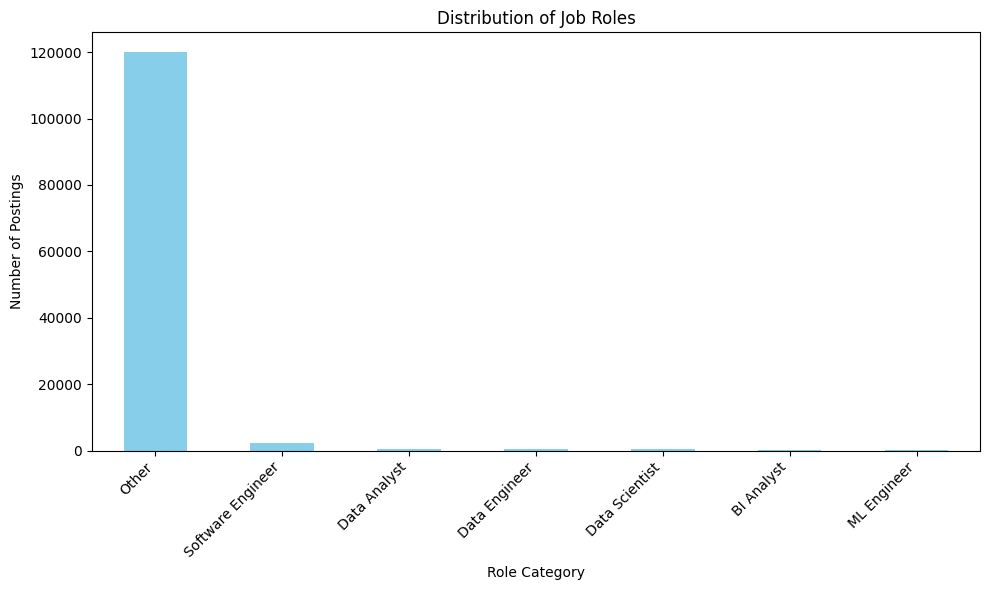

In [3]:
# Chart 1: Role Distribution
plt.figure(figsize=(10, 6))
role_counts = df['role_category'].value_counts()
role_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Job Roles')
plt.xlabel('Role Category')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(fig_dir / 'role_distribution.png')
plt.show()

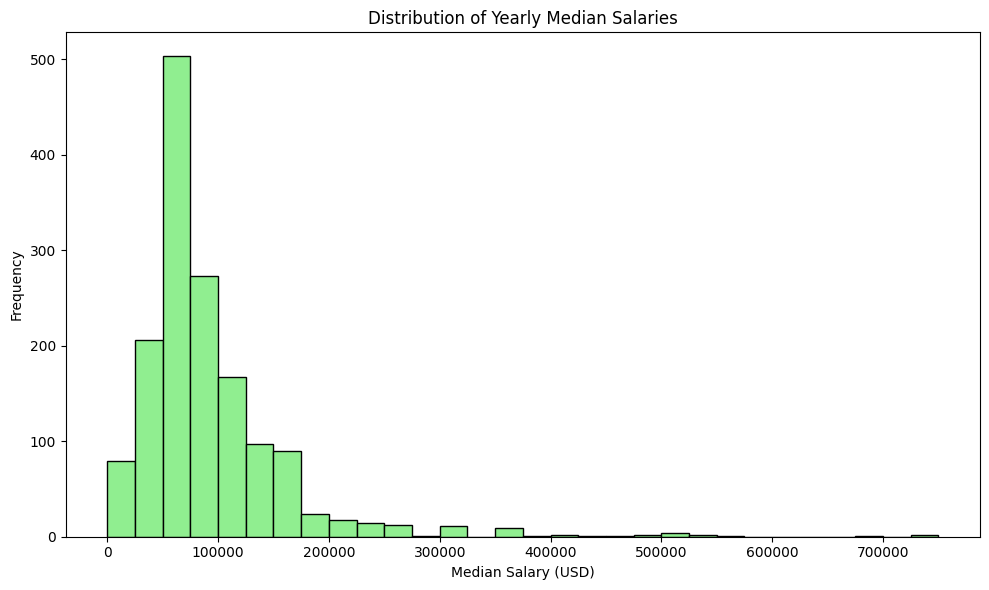

In [4]:
# Chart 2: Salary Distribution
plt.figure(figsize=(10, 6))
yearly_salaries = df[(df['pay_period'] == 'YEARLY') & (df['med_salary'].notna())]
if not yearly_salaries.empty:
    plt.hist(yearly_salaries['med_salary'], bins=30, color='lightgreen', edgecolor='black')
    plt.title('Distribution of Yearly Median Salaries')
    plt.xlabel('Median Salary (USD)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(fig_dir / 'salary_distribution.png')
plt.show()

In [5]:
# Chart 3: Top Job Functions Overall
plt.figure(figsize=(10, 6))
all_job_functions = df['job_functions'].explode().dropna()
all_job_functions = all_job_functions[all_job_functions != ""]
top_job_functions = all_job_functions.value_counts().head(15)
if not top_job_functions.empty:
    top_job_functions.plot(kind='barh', color='salmon')
    plt.title('Top 15 Job Functions Across All Roles')
    plt.xlabel('Frequency')
    plt.ylabel('Job Function')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(fig_dir / 'top_job_functions.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

In [6]:
df.columns.tolist()
df["pay_period"].value_counts(dropna=False).head(20)

pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

In [7]:
import pandas as pd

df = pd.read_parquet("../data/processed/jobs_features.parquet")

salary_df = df[df["pay_period"] == "YEARLY"].copy()

salary_df = salary_df[
    (salary_df["max_salary"] > 10000) &
    (salary_df["max_salary"] < 1000000)
]

print("YEARLY salary sample size:", len(salary_df))
salary_df["max_salary"].describe()

YEARLY salary sample size: 18716


count     18716.000000
mean     138404.515625
std       76779.734375
min       12000.000000
25%       85000.000000
50%      120000.000000
75%      170000.000000
max      998426.000000
Name: max_salary, dtype: float64

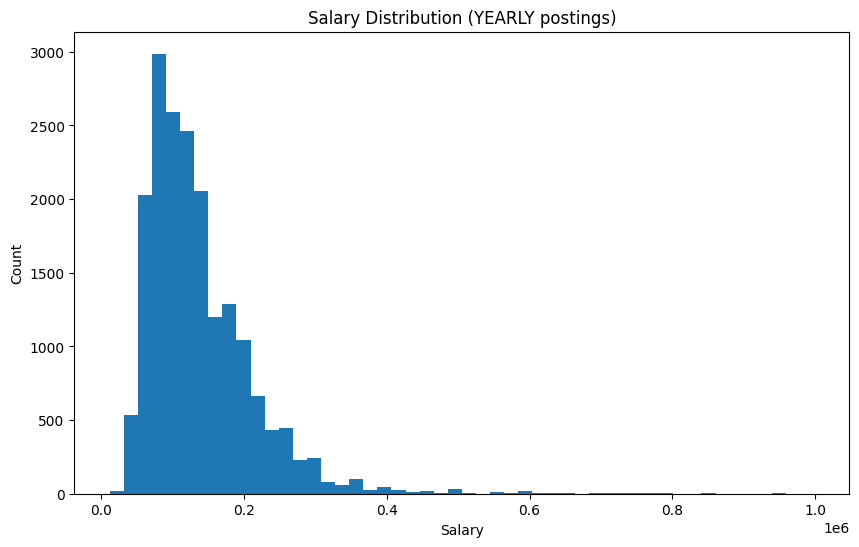

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(salary_df["max_salary"], bins=50)

plt.title("Salary Distribution (YEARLY postings)")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

In [11]:
import pandas as pd

df = pd.read_parquet("../data/processed/jobs_features.parquet")
print("Columns:", df.columns.tolist())

Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'role_category', 'skills']


In [12]:
[c for c in df.columns if "role" in c.lower()]

['role_category']

Using role column: role_category


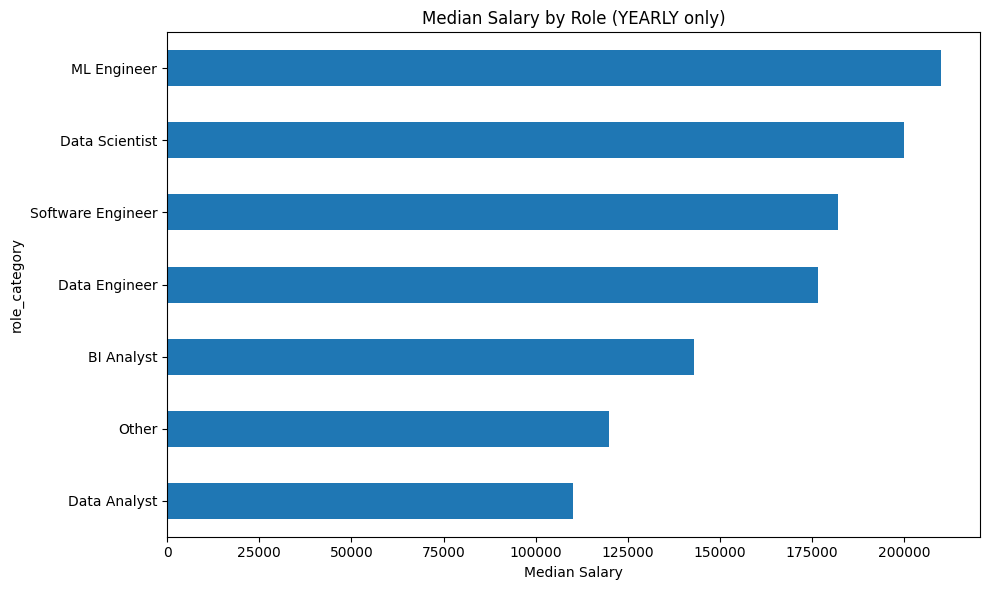

In [13]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/jobs_features.parquet")

# Salary: only YEARLY + sensible range
salary_df = df[df["pay_period"] == "YEARLY"].copy()
salary_df = salary_df[(salary_df["max_salary"] > 10_000) & (salary_df["max_salary"] < 1_000_000)]

# Find role column robustly
role_candidates = [c for c in salary_df.columns if c.lower() in ["role", "job_role", "role_taxonomy", "role_label"]]
if not role_candidates:
    # fallback: any column containing "role"
    role_candidates = [c for c in salary_df.columns if "role" in c.lower()]

if not role_candidates:
    raise KeyError("No role-like column found. Print df.columns and ensure features pipeline writes role column.")

role_col = role_candidates[0]
print("Using role column:", role_col)

role_salary = salary_df.groupby(role_col)["max_salary"].median().sort_values()

plt.figure(figsize=(10, 6))
role_salary.plot(kind="barh")
plt.title("Median Salary by Role (YEARLY only)")
plt.xlabel("Median Salary")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

df = pd.read_parquet("../data/processed/jobs_features.parquet")
df.columns.tolist()

['job_id',
 'company_name',
 'title',
 'description',
 'max_salary',
 'pay_period',
 'location',
 'company_id',
 'views',
 'med_salary',
 'min_salary',
 'formatted_work_type',
 'applies',
 'original_listed_time',
 'remote_allowed',
 'job_posting_url',
 'application_url',
 'application_type',
 'expiry',
 'closed_time',
 'formatted_experience_level',
 'skills_desc',
 'listed_time',
 'posting_domain',
 'sponsored',
 'work_type',
 'currency',
 'compensation_type',
 'normalized_salary',
 'zip_code',
 'fips',
 'role_category',
 'skills']

In [16]:
[c for c in df.columns if "skill" in c.lower()]

['skills_desc', 'skills']

In [17]:
import pandas as pd

df = pd.read_parquet("../data/processed/jobs_features.parquet")

# find a skills column
skill_candidates = [c for c in df.columns if c.lower() in ["skills_list", "job_functions", "skill_names", "skills_names", "skills_joined"]]
if not skill_candidates:
    skill_candidates = [c for c in df.columns if "skill" in c.lower()]

if not skill_candidates:
    raise KeyError("No skills-like column found. Print df.columns and check pipeline export.")

skills_col = skill_candidates[0]
print("Using skills column:", skills_col)

# peek + type distribution
print(df[skills_col].head(5))
print(df[skills_col].apply(type).value_counts().head(5))

Using skills column: skills
0    []
1    []
2    []
3    []
4    []
Name: skills, dtype: object
skills
<class 'numpy.ndarray'>    123849
Name: count, dtype: int64


In [18]:
import numpy as np

# boş mu dolu mu say
nonempty = df["job_functions"].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 0)
print("Total rows:", len(df))
print("Non-empty skills rows:", nonempty.sum())
print("Non-empty ratio:", nonempty.mean())

Total rows: 123849
Non-empty skills rows: 0
Non-empty ratio: 0.0


In [21]:
from src.io import load_postings, load_job_skills

postings_10k = load_postings(nrows=10000, chunksize=None)  # küçük örnek
job_sk = load_job_skills()

print("postings job_id dtype:", postings_10k["job_id"].dtype)
print("job_skills job_id dtype:", job_sk["job_id"].dtype)

post_ids = set(postings_10k["job_id"].astype(str))
skill_ids = set(job_sk["job_id"].astype(str))

print("Intersection (10k postings vs job_skills):", len(post_ids & skill_ids))

postings job_id dtype: Int64
job_skills job_id dtype: Int64
Intersection (10k postings vs job_skills): 9728


In [22]:
import pandas as pd
import numpy as np

nonempty = df["job_functions"].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 0)
job_functions_exploded = df.loc[nonempty, ["job_functions"]].explode("job_functions")

top_job_functions = job_functions_exploded["job_functions"].value_counts().head(30)
top_job_functions

Series([], Name: count, dtype: int64)

In [ ]:
# Chart 4: Top Tech Skills Overall
plt.figure(figsize=(10, 6))
all_tech_skills = df['tech_skills'].explode().dropna()
all_tech_skills = all_tech_skills[all_tech_skills != ""]
top_tech_skills = all_tech_skills.value_counts().head(15)
if not top_tech_skills.empty:
    top_tech_skills.plot(kind='barh', color='mediumpurple')
    plt.title('Top 15 Technical Skills Across All Roles')
    plt.xlabel('Frequency')
    plt.ylabel('Tech Skill')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(fig_dir / 'top_tech_skills.png')
plt.show()

In [ ]:
# Chart 5: Top Tech Skills by Role Category
top_roles = df['role_category'].value_counts().head(4).index
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, role in enumerate(top_roles):
    role_skills = df[df['role_category'] == role]['tech_skills'].explode().dropna()
    role_skills = role_skills[role_skills != ""]
    top_role_skills = role_skills.value_counts().head(10)
    if not top_role_skills.empty:
        top_role_skills.plot(kind='barh', ax=axes[i], color='cornflowerblue')
        axes[i].set_title(f'Top Tech Skills for {role}')
        axes[i].invert_yaxis()
plt.tight_layout()
plt.savefig(fig_dir / 'top_tech_skills_by_role.png')
plt.show()

## Tech Skill Co-occurrence Analysis
Let's see which technical skills commonly appear together in job descriptions.

In [ ]:
# Chart 6: Tech Skill Co-occurrence Heatmap
import numpy as np
from collections import Counter
from itertools import combinations

print('Generating Tech Skill Co-occurrence...')
co_counts = Counter()
for skills_list in df['tech_skills'].dropna():
    if not isinstance(skills_list, (list, np.ndarray)) or len(skills_list) < 2:
        continue
    skills_list = sorted([s for s in skills_list if s])
    co_counts.update(combinations(skills_list, 2))

if co_counts:
    # Get top 20 skills by overall frequency to limit the heatmap size
    all_skills = df['tech_skills'].explode().dropna()
    all_skills = all_skills[all_skills != ""]
    top_n = all_skills.value_counts().head(20).index.tolist()
    
    # Build matrix
    co_matrix = pd.DataFrame(0, index=top_n, columns=top_n)
    for (s1, s2), count in co_counts.items():
        if s1 in top_n and s2 in top_n:
            co_matrix.loc[s1, s2] = count
            co_matrix.loc[s2, s1] = count
            
    # Plot heatmap using matplotlib
    plt.figure(figsize=(12, 10))
    plt.imshow(co_matrix, cmap='Blues', interpolation='nearest', aspect='auto')
    plt.colorbar(label='Co-occurrence Count')
    plt.xticks(range(len(top_n)), top_n, rotation=90)
    plt.yticks(range(len(top_n)), top_n)
    plt.title('Top Tech Skills Co-occurrence (Heatmap)')
    plt.tight_layout()
    plt.savefig(fig_dir / 'tech_skill_cooccurrence.png')
    plt.show()
